**Football Player Performance Analysis Across Teams and Leagues**

> *This project focuses on analyzing football player performance using a dataset containing statistics such as goals, assists, matches played, minutes played, and other performance metrics. Using Python libraries like Pandas, Matplotlib, and Seaborn, the dataset is cleaned, explored, and visualized to identify patterns in player performance. The analysis helps compare players across teams and leagues and highlights key insights about scoring ability, playing time, and overall contribution.*

> Football is one of the most popular sports worldwide, and player performance data is widely analyzed by teams, analysts, and sports organizations to improve team strategies and player development. Analyzing football player statistics such as goals, assists, matches played, and shooting accuracy helps identify performance patterns and evaluate player contributions to their teams.
> 
> 
> 
> This project is relevant because data analytics plays an important role in modern sports analysis. By applying data cleaning, exploratory data analysis, and visualization techniques, meaningful insights can be extracted from player performance data. The analysis helps understand relationships between different performance metrics and highlights trends across players and teams.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os
os.getcwd()

'c:\\Users\\91735\\Desktop\\AI Driven Data Analysis\\Python\\Python Project'

## Data Loading

The dataset is loaded into the Python environment using the Pandas library. This step allows us to access and manipulate the data for further analysis.

In [4]:
df = pd.read_excel(r"C:\Users\91735\Desktop\AI Driven Data Analysis\Python\Python Project\football_players_data.xlsx")

In [5]:
df = pd.read_excel("C:/Users/91735/Desktop/AI Driven Data Analysis/Python/Python Project/football_players_data.xlsx")

In [6]:
df.head()

,Player,Team,League,Season,Position,Age,Matches_Played,Minutes_Played,Goals,Assists,Shots,Shots_On_Target,Pass_Accuracy_%,Yellow_Cards,Red_Cards
0,Leroy Sane,Bayern Munich,Bundesliga,2022/23,LW,35,22,2624,6,11,84,72,82.30,3,1
1,Memphis Depay,Atletico Madrid,La Liga,2022/23,LW,29,23,3028,6,7,84,26,94.26,4,0
2,Lionel Messi,Inter Miami,MLS,2022/23,CAM,19,11,1396,21,8,119,14,74.58,6,0
3,Erling Haaland,Manchester City,Premier League,2022/23,RW,34,20,1696,35,12,47,55,76.85,1,0
4,Erling Haaland,Manchester City,Premier League,2020/21,RW,32,5,1877,27,2,97,15,69.94,3,1


This step displays the first five rows of the dataset to understand its structure and contents.

## Dataset Description

The dataset contains 1000 records and 15 columns, including player names, teams, leagues, and performance-related attributes such as goals, assists, matches played, and pass accuracy. The dataset includes both numerical and categorical variables, making it suitable for exploratory data analysis.

In [7]:
df.shape

(1000, 15)

The dataset contains 1000 rows and 15 columns, representing football players and their performance statistics.

In [8]:

duplicates = df.sample(10)

df = pd.concat([df, duplicates], ignore_index=True)

df.duplicated().sum()

np.int64(10)

In [9]:
import numpy as np

df.loc[5:10, "Goals"] = np.nan
df.loc[15:20, "Assists"] = np.nan

In [10]:
df.isnull().sum()

Player             0
Team               0
League             0
Season             0
Position           0
Age                0
Matches_Played     0
Minutes_Played     0
Goals              6
Assists            6
Shots              0
Shots_On_Target    0
Pass_Accuracy_%    0
Yellow_Cards       0
Red_Cards          0
dtype: int64

In [11]:
df = df.drop_duplicates()

df.duplicated().sum()

np.int64(0)

In [12]:
df["Goals"] = df["Goals"].fillna(df["Goals"].mean())
df["Assists"] = df["Assists"].fillna(df["Assists"].mean())

In [13]:
df.isnull().sum()

Player             0
Team               0
League             0
Season             0
Position           0
Age                0
Matches_Played     0
Minutes_Played     0
Goals              0
Assists            0
Shots              0
Shots_On_Target    0
Pass_Accuracy_%    0
Yellow_Cards       0
Red_Cards          0
dtype: int64

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Player           1000 non-null   str    
 1   Team             1000 non-null   str    
 2   League           1000 non-null   str    
 3   Season           1000 non-null   str    
 4   Position         1000 non-null   str    
 5   Age              1000 non-null   int64  
 6   Matches_Played   1000 non-null   int64  
 7   Minutes_Played   1000 non-null   int64  
 8   Goals            1000 non-null   float64
 9   Assists          1000 non-null   float64
 10  Shots            1000 non-null   int64  
 11  Shots_On_Target  1000 non-null   int64  
 12  Pass_Accuracy_%  1000 non-null   float64
 13  Yellow_Cards     1000 non-null   int64  
 14  Red_Cards        1000 non-null   int64  
dtypes: float64(3), int64(7), str(5)
memory usage: 117.3 KB


This shows:

a) column names

b) data types

c) missing values

In [15]:
df.describe()

,Age,Matches_Played,Minutes_Played,Goals,Assists,Shots,Shots_On_Target,Pass_Accuracy_%,Yellow_Cards,Red_Cards
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,26.272000,21.202000,1773.281000,19.882294,9.633803,77.18000,45.644000,79.625570,4.499000,0.470000
std,5.187381,9.587655,830.960981,11.597574,5.672643,41.31063,25.056158,8.540497,2.823822,0.499349
min,18.000000,5.000000,300.000000,0.000000,0.000000,5.00000,2.000000,65.020000,0.000000,0.000000
25%,22.000000,13.000000,1048.750000,10.000000,5.000000,40.00000,23.000000,72.125000,2.000000,0.000000
50%,26.000000,22.000000,1827.000000,20.000000,10.000000,77.00000,47.000000,79.520000,4.500000,0.000000
75%,31.000000,30.000000,2491.750000,30.000000,15.000000,113.00000,68.000000,86.975000,7.000000,1.000000
max,35.000000,37.000000,3196.000000,39.000000,19.000000,149.00000,89.000000,94.900000,9.000000,1.000000


This provides statistical measures such as mean, standard deviation, minimum, and maximum values for numerical columns.

### Handling Missing Values

Missing values were handled using the mean imputation method. This approach replaces missing values with the average of the column, ensuring that the dataset remains consistent without losing important information.

In [16]:
df.isnull().sum()

Player             0
Team               0
League             0
Season             0
Position           0
Age                0
Matches_Played     0
Minutes_Played     0
Goals              0
Assists            0
Shots              0
Shots_On_Target    0
Pass_Accuracy_%    0
Yellow_Cards       0
Red_Cards          0
dtype: int64

This checks if any column contains missing values.

In [17]:
df = df.drop_duplicates()

Duplicate records are removed to maintain data accuracy.

In [18]:
df.dtypes

Player                 str
Team                   str
League                 str
Season                 str
Position               str
Age                  int64
Matches_Played       int64
Minutes_Played       int64
Goals              float64
Assists            float64
Shots                int64
Shots_On_Target      int64
Pass_Accuracy_%    float64
Yellow_Cards         int64
Red_Cards            int64
dtype: object

### Feature Engineering

A new feature called "Goals per Match" was created to evaluate player efficiency. This helps in understanding how effectively a player scores goals relative to the number of matches played.

In [19]:
df["Goals_per_Match"] = df["Goals"] / df["Matches_Played"]

A new column called Goals per Match is created to evaluate player scoring efficiency.

In [20]:
df.head()

,Player,Team,League,Season,Position,Age,Matches_Played,Minutes_Played,Goals,Assists,Shots,Shots_On_Target,Pass_Accuracy_%,Yellow_Cards,Red_Cards,Goals_per_Match
0,Leroy Sane,Bayern Munich,Bundesliga,2022/23,LW,35,22,2624,6.0,11.0,84,72,82.30,3,1,0.272727
1,Memphis Depay,Atletico Madrid,La Liga,2022/23,LW,29,23,3028,6.0,7.0,84,26,94.26,4,0,0.260870
2,Lionel Messi,Inter Miami,MLS,2022/23,CAM,19,11,1396,21.0,8.0,119,14,74.58,6,0,1.909091
3,Erling Haaland,Manchester City,Premier League,2022/23,RW,34,20,1696,35.0,12.0,47,55,76.85,1,0,1.750000
4,Erling Haaland,Manchester City,Premier League,2020/21,RW,32,5,1877,27.0,2.0,97,15,69.94,3,1,5.400000


In [21]:
top_scorers = df[df["Goals"] > 10]
top_scorers.head()

,Player,Team,League,Season,Position,Age,Matches_Played,Minutes_Played,Goals,Assists,Shots,Shots_On_Target,Pass_Accuracy_%,Yellow_Cards,Red_Cards,Goals_per_Match
2,Lionel Messi,Inter Miami,MLS,2022/23,CAM,19,11,1396,21.000000,8.0,119,14,74.58,6,0,1.909091
3,Erling Haaland,Manchester City,Premier League,2022/23,RW,34,20,1696,35.000000,12.0,47,55,76.85,1,0,1.750000
4,Erling Haaland,Manchester City,Premier League,2020/21,RW,32,5,1877,27.000000,2.0,97,15,69.94,3,1,5.400000
5,Rodrygo,Real Madrid,La Liga,2021/22,CF,28,12,1198,19.882294,16.0,72,31,86.36,3,0,1.656858
6,Sadio Mane,Al Nassr,Saudi Pro League,2019/20,LW,28,16,2818,19.882294,1.0,110,83,85.20,6,0,1.242643


This filters players who scored more than 10 goals.

### Top 10 Goal Scorers

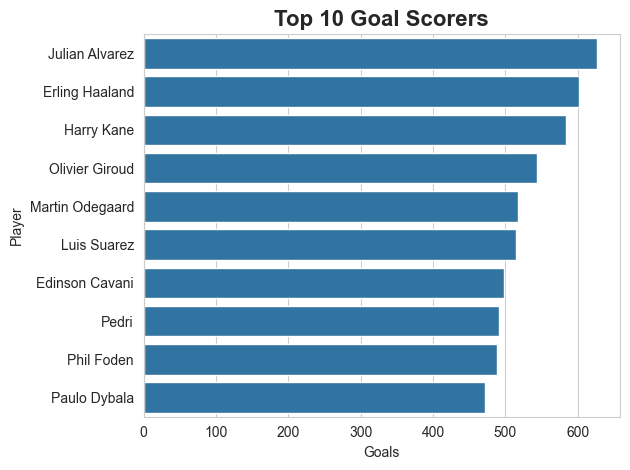

In [11]:
top_players = df.groupby("Player")["Goals"].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_players.values, y=top_players.index)

plt.title("Top 10 Goal Scorers", fontsize=16, fontweight="bold")
plt.xlabel("Goals")
plt.ylabel("Player")

plt.tight_layout()
plt.show()

> This chart shows the top 10 players with the highest number of goals, highlighting the most effective goal scorers in the dataset.

### Distribution of Goals

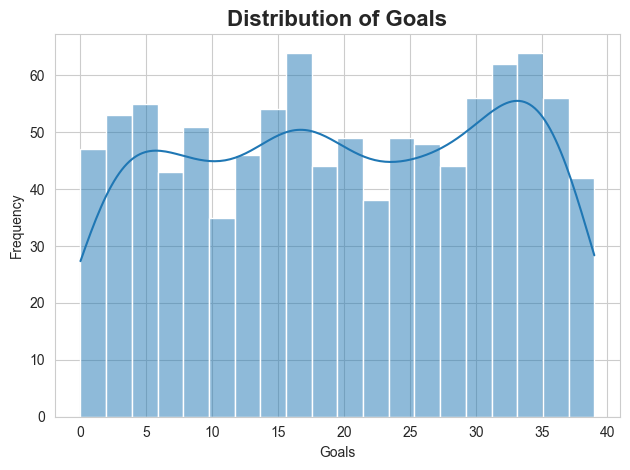

In [15]:
sns.histplot(df["Goals"], bins=20, kde=True)

plt.title("Distribution of Goals", fontsize=16, fontweight="bold")
plt.xlabel("Goals")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

> This visualization shows how goals are distributed among players, indicating the frequency of different goal ranges.

### Goals vs Assists

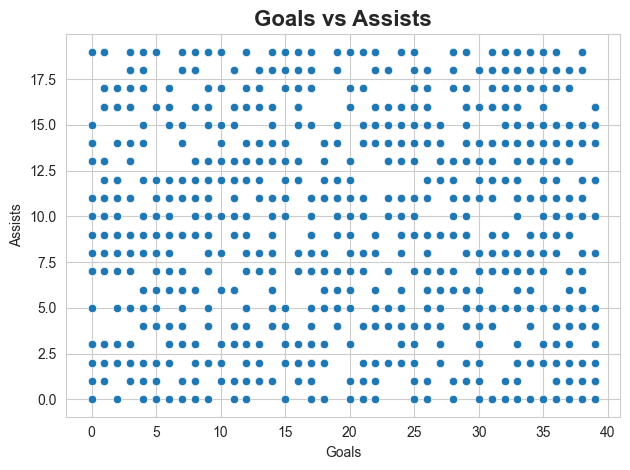

In [16]:
sns.scatterplot(x=df["Goals"], y=df["Assists"])

plt.title("Goals vs Assists", fontsize=16, fontweight="bold")
plt.xlabel("Goals")
plt.ylabel("Assists")

plt.tight_layout()
plt.show()

> This chart illustrates the relationship between goals and assists, showing how players contribute both in scoring and assisting.

### Matches Played vs Goals

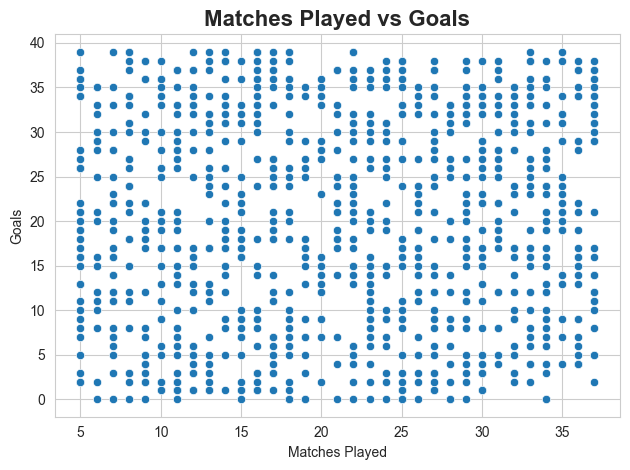

In [17]:
sns.scatterplot(x=df["Matches_Played"], y=df["Goals"])

plt.title("Matches Played vs Goals", fontsize=16, fontweight="bold")
plt.xlabel("Matches Played")
plt.ylabel("Goals")

plt.tight_layout()
plt.show()

> This visualization shows how the number of matches played influences goal scoring performance.

### Average Goals by League

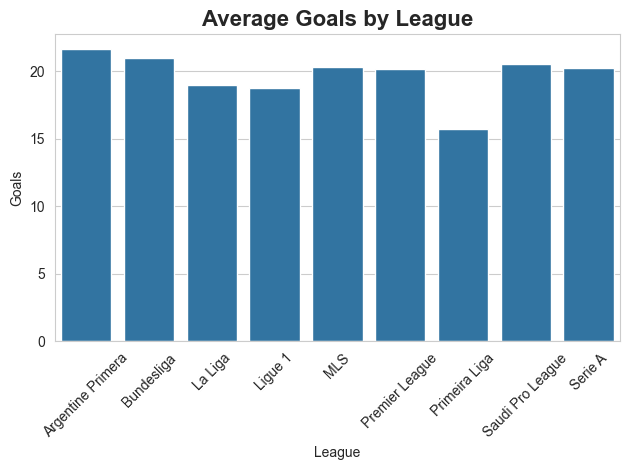

In [18]:
league_goals = df.groupby("League")["Goals"].mean().reset_index()

sns.barplot(x="League", y="Goals", data=league_goals)

plt.title("Average Goals by League", fontsize=16, fontweight="bold")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

> This chart compares the average goals scored across different leagues, highlighting performance differences.

### Age vs Goals

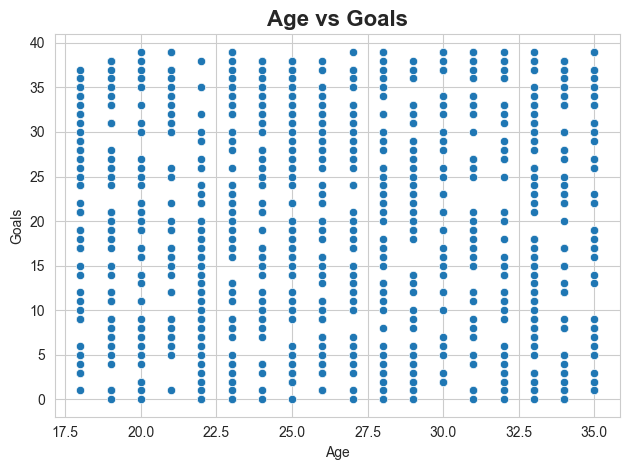

In [19]:
sns.scatterplot(x=df["Age"], y=df["Goals"])

plt.title("Age vs Goals", fontsize=16, fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Goals")

plt.tight_layout()
plt.show()

> This chart shows how player age affects goal scoring performance.

### Pass Accuracy Distribution

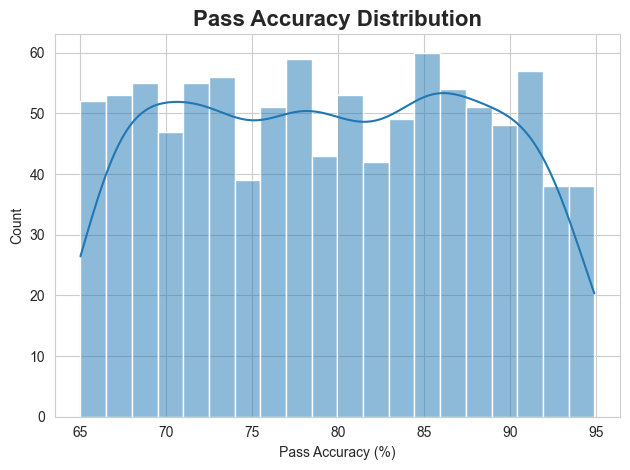

In [20]:
sns.histplot(df["Pass_Accuracy_%"], bins=20, kde=True)

plt.title("Pass Accuracy Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Pass Accuracy (%)")

plt.tight_layout()
plt.show()

> This visualization shows how pass accuracy is distributed among players.

### Top Teams by Goals

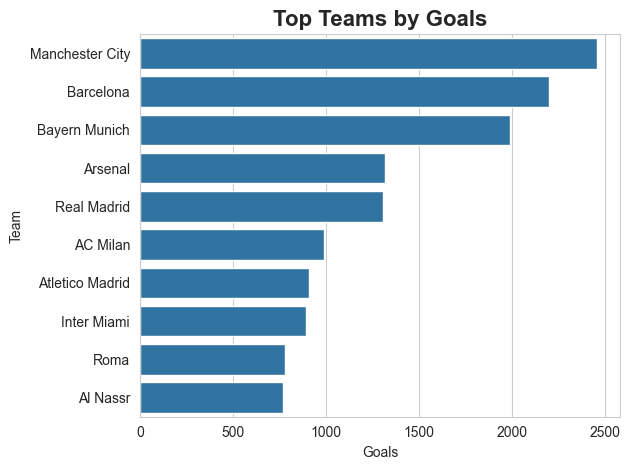

In [21]:
team_goals = df.groupby("Team")["Goals"].sum().sort_values(ascending=False).head(10)

sns.barplot(x=team_goals.values, y=team_goals.index)

plt.title("Top Teams by Goals", fontsize=16, fontweight="bold")
plt.xlabel("Goals")

plt.tight_layout()
plt.show()

> This chart highlights the teams with the highest total goals scored.

### Yellow Cards Distribution

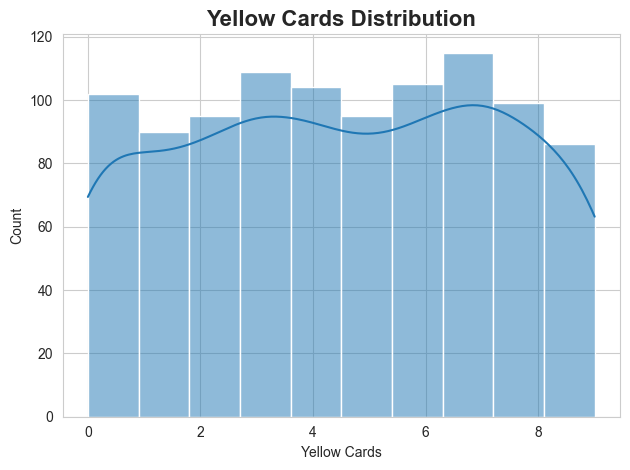

In [22]:
sns.histplot(df["Yellow_Cards"], bins=10, kde=True)

plt.title("Yellow Cards Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Yellow Cards")

plt.tight_layout()
plt.show()

> This visualization shows the distribution of yellow cards among players, indicating discipline levels.

### Correlation Heatmap

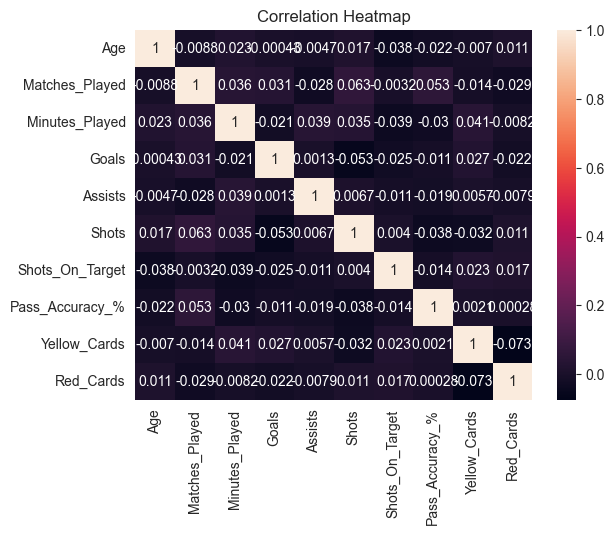

In [24]:
import seaborn as sns

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

> This heatmap shows the relationships between numerical variables, helping identify correlations in player performance.

# Key Insights

## Goals vs Matches Played

Players who have played more matches tend to score more goals, indicating a positive relationship between playing time and goal contribution.

## Goals vs Assists Relationship

There is a moderate positive relationship between goals and assists, suggesting that players who contribute to scoring also tend to assist goals.

## League-wise Performance Variation

The average number of goals varies across different leagues, indicating differences in playing style, competition level, or player quality.

## Age vs Performance

Players in the mid-age range tend to perform better in terms of goal scoring, while very young and older players show relatively lower performance.

## Shots on Target Impact

Players with a higher number of shots on target generally score more goals, highlighting the importance of shooting accuracy in performance.

*Teams with higher total goals often have multiple high-performing players, indicating that team success depends on collective contribution rather than individual performance.*

# Final Conclusion

*This project successfully analyzed football player performance using data analytics techniques. Through data cleaning, exploratory data analysis, and visualization, key insights were identified regarding player efficiency, team performance, and relationships between different performance metrics. The analysis demonstrates how data-driven approaches can be used to evaluate and understand sports performance.*